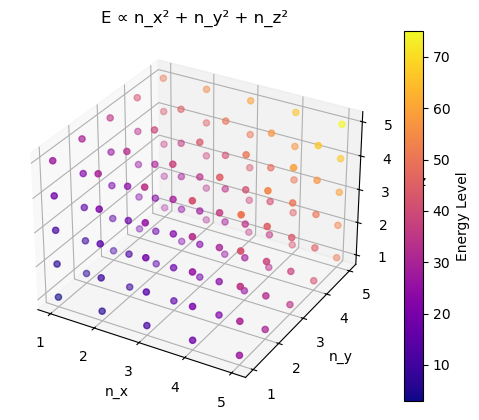

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 量子数の範囲
n = np.arange(1, 6)
points = []
for nx in n:
    for ny in n:
        for nz in n:
            E = nx**2 + ny**2 + nz**2
            points.append((nx, ny, nz, E))

# エネルギーが近い点ほど色を変える
points = np.array(points)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(points[:,0], points[:,1], points[:,2],
               c=points[:,3], cmap='plasma')

ax.set_xlabel('n_x')
ax.set_ylabel('n_y')
ax.set_zlabel('n_z')
ax.set_title('E ∝ n_x² + n_y² + n_z²')
plt.colorbar(p, label='Energy Level')
plt.show()



<>:38: SyntaxWarning: invalid escape sequence '\g'
<>:44: SyntaxWarning: invalid escape sequence '\i'
<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\g'
<>:62: SyntaxWarning: invalid escape sequence '\h'
<>:38: SyntaxWarning: invalid escape sequence '\g'
<>:44: SyntaxWarning: invalid escape sequence '\i'
<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\g'
<>:62: SyntaxWarning: invalid escape sequence '\h'
C:\Users\jupik\AppData\Local\Temp\ipykernel_19428\3465159373.py:38: SyntaxWarning: invalid escape sequence '\g'
  plt.hlines(E_1d_fixed, xmin=0, xmax=1, color='blue', linestyle='-', linewidth=2, label='1D 固定端条件 ($n \geq 1$)')
C:\Users\jupik\AppData\Local\Temp\ipykernel_19428\3465159373.py:44: SyntaxWarning: invalid escape sequence '\i'
  plt.hlines(E_1d_periodic, xmin=1.5, xmax=2.5, color='red', linestyle='-', linewidth=2, label='1D 周期的境界条件 ($n \in \mathbb{Z}$)')
C:\Users\jupik\AppData

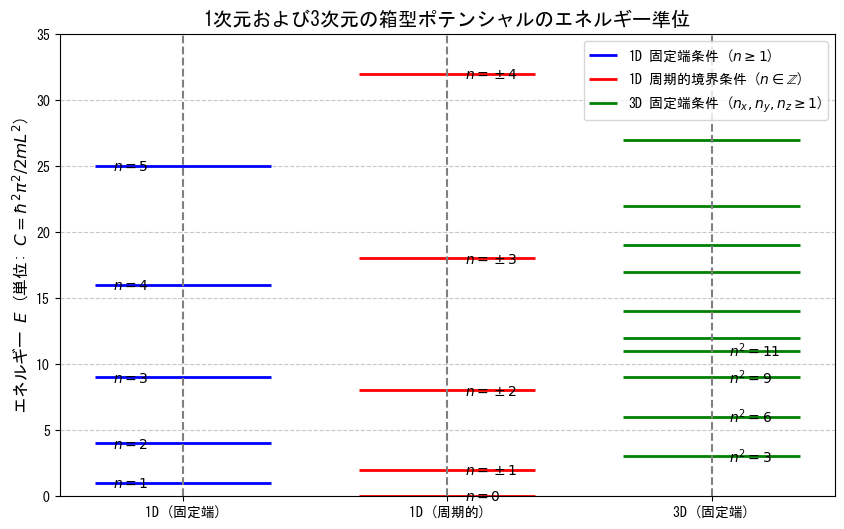

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "MS Gothic"

# 定数項をまとめて C = (hbar^2 * pi^2) / (2 * m * L^2) とする
C = 1.0 

# (i) 固定端条件 (1次元)
n_1d = np.arange(1, 6) # n = 1, 2, 3, 4, 5
E_1d_fixed = C * n_1d**2

# (ii) 周期的境界条件 (1次元)
n_1d_periodic = np.arange(0, 5) # n = 0, 1, 2, 3, 4
E_1d_periodic = (2 * C) * n_1d_periodic**2 
# 周期的境界条件のエネルギーは、固定端の4倍 E_n = (4*pi^2*hbar^2)/(2*m*L^2) * n^2 = 4 * C * n^2 (n=0, 1, 2, ...)
# ただし、ここでは (2*C) * n^2 と表現することで、プロット上での差を明確にする

# 3次元箱型ポテンシャル
# n_x, n_y, n_z = 1, 2, 3, ... の組み合わせ
states_3d = []
for nx in range(1, 4):
    for ny in range(1, 4):
        for nz in range(1, 4):
            E = nx**2 + ny**2 + nz**2
            # 既にリストに存在しないエネルギー値と量子数の組を保存
            if E not in [s[0] for s in states_3d]:
                states_3d.append((E, nx, ny, nz))
            
# エネルギーの昇順にソート
states_3d.sort(key=lambda x: x[0])
E_3d_values = C * np.array([s[0] for s in states_3d])

# グラフ描画
plt.figure(figsize=(10, 6))

# 1次元 固定端条件
plt.hlines(E_1d_fixed, xmin=0, xmax=1, color='blue', linestyle='-', linewidth=2, label='1D 固定端条件 ($n \geq 1$)')
plt.vlines(0.5, ymin=0, ymax=E_1d_fixed[-1] + 10 * C, color='gray', linestyle='--')
for i, E in enumerate(E_1d_fixed):
    plt.text(0.1, E, f'$n={n_1d[i]}$', va='center')
    
# 1次元 周期的境界条件
plt.hlines(E_1d_periodic, xmin=1.5, xmax=2.5, color='red', linestyle='-', linewidth=2, label='1D 周期的境界条件 ($n \in \mathbb{Z}$)')
plt.vlines(2, ymin=0, ymax=E_1d_fixed[-1] + 10 * C, color='gray', linestyle='--')
# n=0, ±1, ±2, ... のラベル付け (n=±1, ±2 は縮退しているため1つにまとめる)
for i, E in enumerate(E_1d_periodic):
    if n_1d_periodic[i] == 0:
        plt.text(2.1, E, '$n=0$', va='center')
    else:
        plt.text(2.1, E, f'$n=\pm{n_1d_periodic[i]}$', va='center')
        
# 3次元箱型ポテンシャル
plt.hlines(E_3d_values, xmin=3, xmax=4, color='green', linestyle='-', linewidth=2, label='3D 固定端条件 ($n_x, n_y, n_z \geq 1$)')
plt.vlines(3.5, ymin=0, ymax=E_1d_fixed[-1] + 10 * C, color='gray', linestyle='--')
# 3Dの量子数ラベル付け（上位3つまで）
for i, E in enumerate(E_3d_values[:4]):
    plt.text(3.6, E, f'$n^2={int(E/C)}$', va='center')

plt.ylim(0, E_1d_fixed[-1] + 10 * C)
plt.title('1次元および3次元の箱型ポテンシャルのエネルギー準位', fontsize=14)
plt.ylabel('エネルギー $E$ (単位: $C = \hbar^2\pi^2 / 2mL^2$)', fontsize=12)
plt.xticks([0.5, 2, 3.5], ['1D (固定端)', '1D (周期的)', '3D (固定端)'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
C:\Users\jupik\AppData\Local\Temp\ipykernel_19428\2641163856.py:35: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('$k$ 空間におけるフェルミ球 ($\mathrm{Free\ Electron\ Model}$)', fontsize=16)


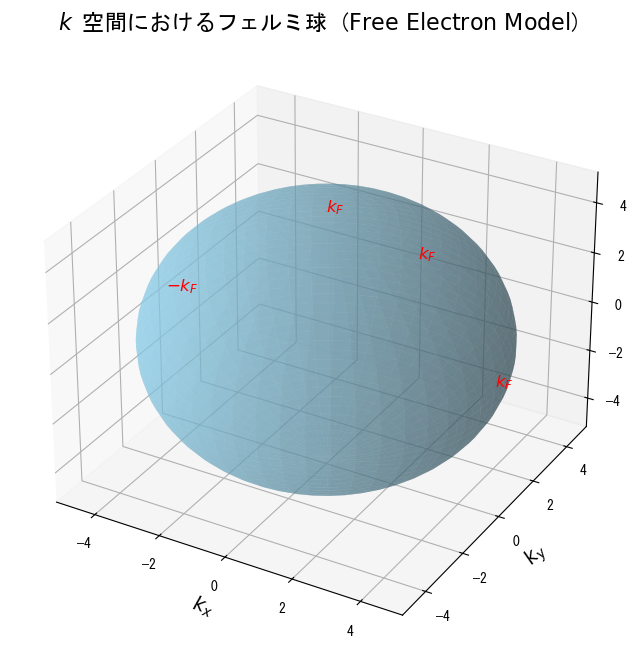

In [3]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "MS Gothic"

# フェルミ波数 k_F の設定
k_F = 5.0

# 描画のための球面座標
phi = np.linspace(0, np.pi, 50)
theta = np.linspace(0, 2 * np.pi, 50)

# メッシュグリッドを作成
phi, theta = np.meshgrid(phi, theta)

# 球面座標からデカルト座標への変換 (半径 k_F の球)
x = k_F * np.sin(phi) * np.cos(theta)
y = k_F * np.sin(phi) * np.sin(theta)
z = k_F * np.cos(phi)

# グラフのセットアップ
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# フェルミ球の表面を描画 (色を薄くして内部を見せる)
ax.plot_surface(x, y, z, color='skyblue', alpha=0.5, rstride=1, cstride=1, linewidth=0)

# k軸のラベル
ax.set_xlabel('$k_x$', fontsize=14)
ax.set_ylabel('$k_y$', fontsize=14)
ax.set_zlabel('$k_z$', fontsize=14)

# タイトル
ax.set_title('$k$ 空間におけるフェルミ球 ($\mathrm{Free\ Electron\ Model}$)', fontsize=16)

# k_F のラベルを付ける
ax.text(k_F, 0, 0, '$k_F$', color='red', fontsize=12)
ax.text(-k_F, 0, 0, '$-k_F$', color='red', fontsize=12)
ax.text(0, k_F, 0, '$k_F$', color='red', fontsize=12)
ax.text(0, 0, k_F, '$k_F$', color='red', fontsize=12)

# 軸の範囲を設定 (対称性を保つため)
ax.set_xlim([-k_F, k_F])
ax.set_ylim([-k_F, k_F])
ax.set_zlim([-k_F, k_F])

# グリッド線を表示
ax.grid(True)

plt.show()

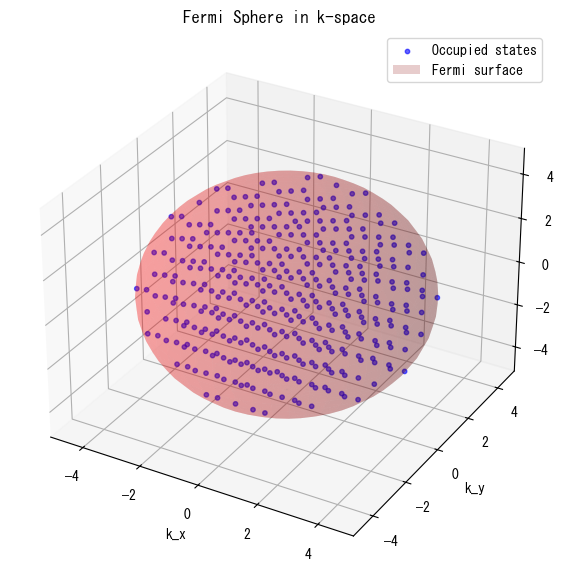

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# k空間の格子点を作成（例: -5〜5）
k = np.arange(-5, 6)
points = []
for kx in k:
    for ky in k:
        for kz in k:
            k_mag = np.sqrt(kx**2 + ky**2 + kz**2)
            points.append((kx, ky, kz, k_mag))

points = np.array(points)
k_F = 4.5  # フェルミ波数の例

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# フェルミ球の内部を青点で描画
inside = points[points[:,3] <= k_F]
ax.scatter(inside[:,0], inside[:,1], inside[:,2],
           color='blue', s=10, alpha=0.6, label='Occupied states')

# フェルミ球の外側を薄く描画
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 25)
x = k_F * np.outer(np.cos(u), np.sin(v))
y = k_F * np.outer(np.sin(u), np.sin(v))
z = k_F * np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(x, y, z, color='red', alpha=0.2, label='Fermi surface')

ax.set_xlabel('k_x')
ax.set_ylabel('k_y')
ax.set_zlabel('k_z')
ax.set_title('Fermi Sphere in k-space')
ax.legend()
plt.show()


<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
C:\Users\jupik\AppData\Local\Temp\ipykernel_19428\1434356781.py:19: SyntaxWarning: invalid escape sequence '\p'
  plt.title("2次元箱型ポテンシャルのエネルギー準位 $E_{n_x,n_y} \propto n_x^2 + n_y^2$")


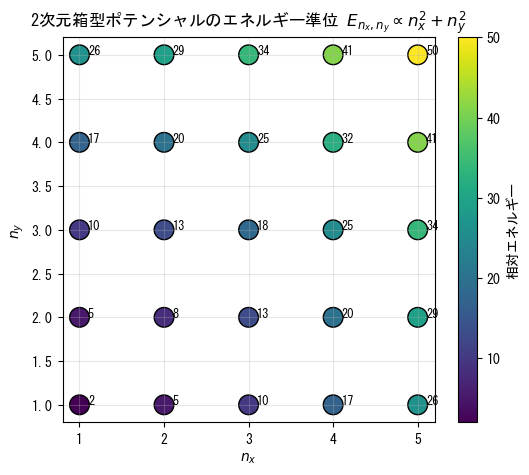

In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "MS Gothic"

# 定義域
n = np.arange(1, 6)
nx, ny = np.meshgrid(n, n)
E = nx**2 + ny**2  # 定数因子は省略して相対値のみ

plt.figure(figsize=(6,5))
plt.scatter(nx, ny, c=E, cmap='viridis', s=200, edgecolors='k')
for i in range(len(n)):
    for j in range(len(n)):
        plt.text(nx[i,j]+0.1, ny[i,j], f"{E[i,j]:.0f}", fontsize=9)

plt.xlabel(r"$n_x$")
plt.ylabel(r"$n_y$")
plt.title("2次元箱型ポテンシャルのエネルギー準位 $E_{n_x,n_y} \propto n_x^2 + n_y^2$")
plt.colorbar(label="相対エネルギー")
plt.grid(True, alpha=0.3)
plt.show()


C:\Users\jupik\AppData\Local\Temp\ipykernel_31568\2165283117.py:20: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp(x) + 1.0)


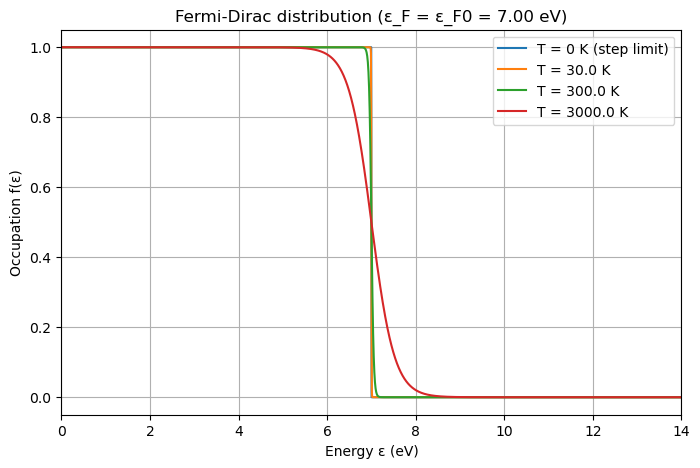

In [1]:
# Python code to compute and plot the Fermi-Dirac distribution
# for ε_F = ε_F0. Change `epsilon_F0` or `T_list` as needed.
import numpy as np
import matplotlib.pyplot as plt

# Physical constant (Boltzmann constant) in eV/K
kB = 8.617333262e-5  # eV/K

def f_fermi(epsilon, epsilon_F0, T):
    """Fermi-Dirac occupation function f(ε) with chemical potential = epsilon_F0.
       T may be zero; handle T=0 as the step function limit.
    """
    epsilon = np.asarray(epsilon)
    if T == 0.0:
        # T = 0 limit: step function
        return np.where(epsilon < epsilon_F0, 1.0, 0.0)
    x = (epsilon - epsilon_F0) / (kB * T)
    # Use exp safely to avoid overflow warnings for large positive x
    # For large positive x, f ~ exp(-x) -> 0; for large negative x, f ~ 1
    return 1.0 / (np.exp(x) + 1.0)

# Parameters (example)
epsilon_F0 = 7.0  # eV, example Fermi energy (replace with desired ε_F,0)
eps_min = 0.0
eps_max = 2.0 * epsilon_F0
eps = np.linspace(eps_min, eps_max, 2000)

# Temperatures to plot (K)
T_list = [0.0, 30.0, 300.0, 3000.0]

plt.figure(figsize=(8,5))
for T in T_list:
    f_vals = f_fermi(eps, epsilon_F0, T)
    label = f"T = {T} K" if T != 0.0 else "T = 0 K (step limit)"
    plt.plot(eps, f_vals, label=label)

plt.xlabel("Energy ε (eV)")
plt.ylabel("Occupation f(ε)")
plt.title("Fermi-Dirac distribution (ε_F = ε_F0 = {:.2f} eV)".format(epsilon_F0))
plt.legend()
plt.grid(True)
plt.xlim(eps_min, eps_max)
plt.ylim(-0.05, 1.05)
plt.show()


C:\Users\jupik\AppData\Local\Temp\ipykernel_31568\992972876.py:29: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp(exponent) + 1.0)


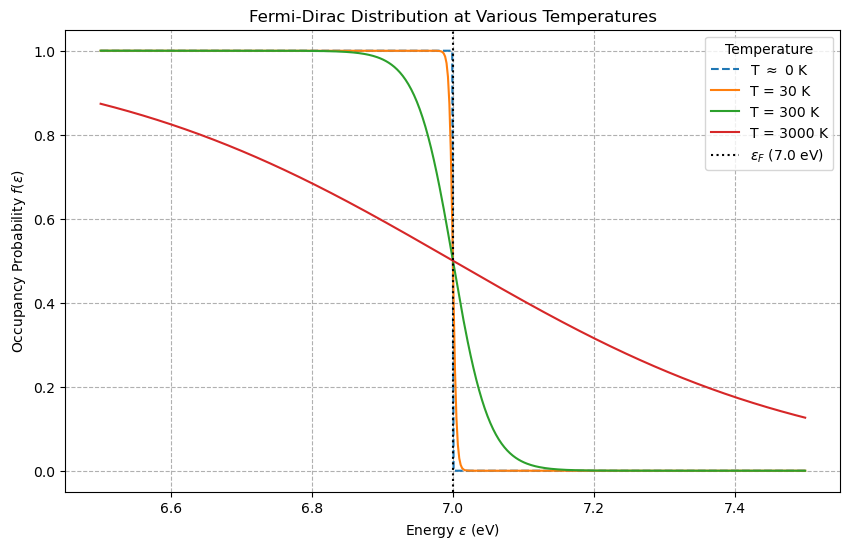

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 定数の設定 ---
# ボルツマン定数 (eV/K)
k_B = 8.617e-5 

# 銅のフェルミエネルギー (eV) - 計算の基準として使用。ここでは値そのものはプロット形状に影響しない。
epsilon_F = 7.0 

# フェルミ分布関数 f(epsilon) の定義
def fermi_distribution(epsilon, epsilon_F, T):
    """
    フェルミ分布関数を計算する。
    epsilon: エネルギー
    epsilon_F: フェルミエネルギー
    T: 絶対温度 (K)
    """
    if T == 0:
        # T=0のときは特殊な場合分けが必要
        return np.where(epsilon < epsilon_F, 1.0, 0.0)
    
    # 指数関数の肩の部分を計算
    exponent = (epsilon - epsilon_F) / (k_B * T)
    
    # オーバーフロー防止（exp(x)が大きくなりすぎないように）
    # ただし、フェルミ準位付近のみを扱うため、この単純な実装で十分なことが多い
    
    return 1.0 / (np.exp(exponent) + 1.0)

# --- 描画するエネルギー範囲の設定 ---
# フェルミエネルギー付近を拡大して見るため、epsilon_Fの前後を設定
delta_epsilon = 0.5 # epsilon_F からの変動幅
epsilon_min = epsilon_F - delta_epsilon
epsilon_max = epsilon_F + delta_epsilon
epsilon = np.linspace(epsilon_min, epsilon_max, 500) # 500点で計算

# --- 温度リスト (K) ---
temperatures = [0.001, 30, 300, 3000] # 0Kは数値的に困難なため、0.001Kを使用

# --- プロット ---
plt.figure(figsize=(10, 6))

for T in temperatures:
    # 0Kの近似 (T=0を厳密に扱うにはnp.whereを使うか、T=0.001など極小値を使う)
    if T == 0.001:
        f_epsilon = fermi_distribution(epsilon, epsilon_F, T)
        plt.plot(epsilon, f_epsilon, label=f'T $\\approx$ 0 K', linestyle='--')
    else:
        f_epsilon = fermi_distribution(epsilon, epsilon_F, T)
        plt.plot(epsilon, f_epsilon, label=f'T = {T:.0f} K')

# グラフの装飾
plt.axvline(x=epsilon_F, color='k', linestyle=':', label='$\\epsilon_F$ (7.0 eV)') # フェルミエネルギーを示す垂直線
plt.title('Fermi-Dirac Distribution at Various Temperatures')
plt.xlabel('Energy $\\epsilon$ (eV)')
plt.ylabel('Occupancy Probability $f(\\epsilon)$')
plt.grid(True, linestyle='--')
plt.legend(title='Temperature')
plt.ylim(-0.05, 1.05)
plt.show()